# Brain-Tumor MRI — Model Comparison Dashboard

**Notebook 06 · cross-model comparison**

A single dashboard that puts every model in the project side by side: the classical-ML
baseline (HOG + SVM), the from-scratch `CustomBrainCNN`, and the transfer-learning
backbones. It answers the deployment question — *which model, and why?* — with accuracy,
efficiency, statistical-significance, and calibration evidence.

**Prerequisites** (this notebook only reads artifacts; it trains nothing):

| Artifact | Produced by |
|---|---|
| `results/leaderboard.json` | `python train.py --compare` |
| `results/{model}_history.pkl` | `train.py` (per-epoch history) |
| `results/{model}_y_true.npy`, `{model}_y_pred.npy`, `{model}_y_prob.npy` | `evaluate_model` in `src/evaluate.py` |
| `results/baseline_results.json` | notebook 02, final cell |

Every section degrades gracefully: if an artifact is missing it prints what to run rather
than crashing, so you can open the dashboard at any stage of the pipeline.

## 0 · Setup & data merge

Load the deep-learning leaderboard and the classical-ML baseline, then merge into one
tidy `DataFrame`. Each model is tagged with a **Type** — `Classical ML`, `Custom CNN`,
or `Transfer Learning` — which drives the colour coding throughout.

In [15]:
import sys, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "results").exists() and (ROOT.parent / "results").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"

from src.evaluate import mcnemar_test            # reused, not reimplemented
from src.config import CLASS_LABELS

# Nominal total parameter counts (millions), used only as a fallback when a
# fresh leaderboard hasn't recorded "params_m" yet. Includes the custom head.
APPROX_PARAMS_M = {
    "resnet50": 23.8, "densenet121": 7.3, "vgg16": 134.6,
    "efficientnet_b0": 4.4, "efficientnet_b3": 11.1, "mobilenet_v3": 4.5,
    "custom_cnn": 11.3, "svm_hog": np.nan,
}

def classify_type(tag: str) -> str:
    if tag in ("svm_hog", "rf_hog") or "svm" in tag or "rf" in tag:
        return "Classical ML"
    if tag == "custom_cnn":
        return "Custom CNN"
    return "Transfer Learning"

def load_json(path):
    return json.loads(Path(path).read_text()) if Path(path).exists() else []

dl_rows = load_json(RESULTS / "leaderboard.json")
ml_rows = load_json(RESULTS / "baseline_results.json")
if not dl_rows:
    print("WARNING: results/leaderboard.json not found — run "
          "`python train.py --compare` first.")
if not ml_rows:
    print("NOTE: results/baseline_results.json not found — run notebook 02's "
          "final cell to include the classical-ML baseline.")

records = []
for r in (ml_rows + dl_rows):
    tag = r["tag"]
    records.append({
        "Model":         tag,
        "Val Acc":       r.get("accuracy"),
        "Macro F1":      r.get("macro_f1"),
        "ROC-AUC":       r.get("macro_roc_auc"),
        "Params(M)":     r.get("params_m") if r.get("params_m") is not None
                         else APPROX_PARAMS_M.get(tag, np.nan),
        "Inference(ms)": r.get("inference_ms", np.nan),
        "ECE":           r.get("ece", np.nan),
        "ECE_cal":       r.get("ece_calibrated", np.nan),  # for section 6
        "Type":          classify_type(tag),
    })

df = pd.DataFrame(records).sort_values("Macro F1", ascending=False,
                                       na_position="last").reset_index(drop=True)
print(f"Loaded {len(df)} models "
      f"({(df['Type'] != 'Classical ML').sum()} deep, "
      f"{(df['Type'] == 'Classical ML').sum()} classical)")
df

Loaded 2 models (1 deep, 1 classical)


,Model,Val Acc,Macro F1,ROC-AUC,Params(M),Inference(ms),ECE,ECE_cal,Type
0,resnet50,0.893878,0.903235,0.988358,24.034116,3.103869,0.036729,0.038055,Transfer Learning
1,svm_hog,0.771574,0.727557,0.945648,NaN,NaN,NaN,NaN,Classical ML


## 1 · Results table

The merged leaderboard, sorted by macro-F1. The **best** value in each numeric column is
highlighted in light green. For *higher-is-better* metrics (accuracy, F1, ROC-AUC) that's
the maximum; for *lower-is-better* metrics (params, latency, ECE) it's the minimum — a
green cell always means "best in column".

In [16]:
DISPLAY_COLS = ["Model", "Val Acc", "Macro F1", "ROC-AUC",
                "Params(M)", "Inference(ms)", "ECE", "Type"]
HIGHER_BETTER = ["Val Acc", "Macro F1", "ROC-AUC"]
LOWER_BETTER  = ["Params(M)", "Inference(ms)", "ECE"]

def highlight_best(col):
    """Light-green the best cell in a column (max if higher-better, else min)."""
    if col.name in HIGHER_BETTER:
        best = col.max()
    elif col.name in LOWER_BETTER:
        best = col.min()
    else:
        return ["" for _ in col]
    return ["background-color: #c6f5c6" if v == best else "" for v in col]

styled = (df[DISPLAY_COLS].style
          .apply(highlight_best, subset=HIGHER_BETTER + LOWER_BETTER)
          .format({"Val Acc": "{:.3f}", "Macro F1": "{:.3f}", "ROC-AUC": "{:.3f}",
                   "Params(M)": "{:.1f}", "Inference(ms)": "{:.2f}", "ECE": "{:.3f}"},
                  na_rep="—")
          .set_caption("Model comparison — sorted by Macro F1"))
styled

,Model,Val Acc,Macro F1,ROC-AUC,Params(M),Inference(ms),ECE,Type
0,resnet50,0.894,0.903,0.988,24.0,3.10,0.037,Transfer Learning
1,svm_hog,0.772,0.728,0.946,—,—,—,Classical ML


## 2 · Accuracy & macro-F1

Side-by-side horizontal bars, sorted by F1 and coloured by model type. Value labels sit
at the end of each bar.

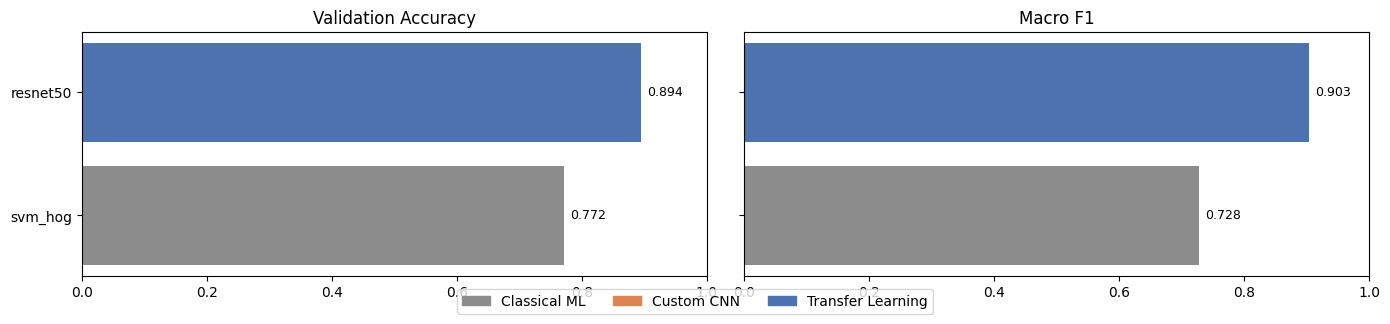

In [17]:
TYPE_COLORS = {"Classical ML": "#8C8C8C", "Custom CNN": "#DD8452",
               "Transfer Learning": "#4C72B0"}

plot_df = df.dropna(subset=["Macro F1"]).sort_values("Macro F1")  # asc -> best on top
colors = [TYPE_COLORS[t] for t in plot_df["Type"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 0.6 * len(plot_df) + 2), sharey=True)
for ax, (col, title) in zip(axes, [("Val Acc", "Validation Accuracy"),
                                    ("Macro F1", "Macro F1")]):
    bars = ax.barh(plot_df["Model"], plot_df[col], color=colors)
    ax.set_title(title); ax.set_xlim(0, 1.0)
    for bar, v in zip(bars, plot_df[col]):
        ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2, f"{v:.3f}",
                va="center", fontsize=9)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TYPE_COLORS.values()]
fig.legend(handles, TYPE_COLORS.keys(), loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

## 3 · Efficiency frontier (accuracy vs. size)

Each model as a point: **x = parameters (M)**, **y = validation accuracy**, marker area
scaled by ROC-AUC. The dashed line is the **Pareto frontier** — the set of models for
which no other model is both smaller *and* more accurate. Models on the frontier are the
rational choices; anything below-and-right of it is dominated.

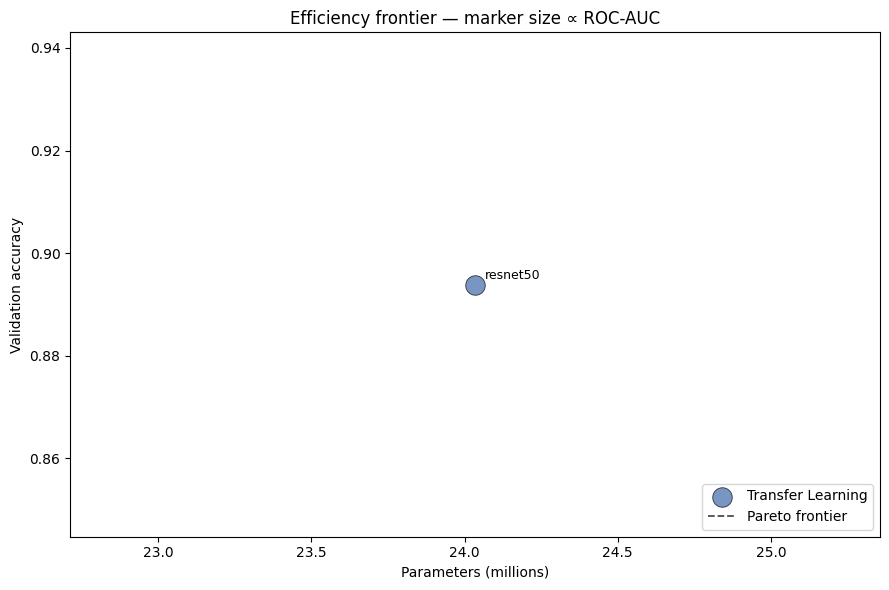

In [18]:
front = df.dropna(subset=["Params(M)", "Val Acc"]).copy()

fig, ax = plt.subplots(figsize=(9, 6))
for t, grp in front.groupby("Type"):
    ax.scatter(grp["Params(M)"], grp["Val Acc"],
               s=grp["ROC-AUC"].fillna(0.5) * 200, alpha=0.75,
               color=TYPE_COLORS[t], edgecolors="k", linewidths=0.6, label=t)
for _, row in front.iterrows():
    ax.annotate(row["Model"], (row["Params(M)"], row["Val Acc"]),
                textcoords="offset points", xytext=(7, 4), fontsize=9)

# Pareto frontier: smallest-to-largest, keep points whose accuracy exceeds the
# best seen so far (no smaller model beats them).
pf = front.sort_values("Params(M)")
frontier, best_acc = [], -np.inf
for _, row in pf.iterrows():
    if row["Val Acc"] > best_acc:
        frontier.append((row["Params(M)"], row["Val Acc"]))
        best_acc = row["Val Acc"]
if frontier:
    fx, fy = zip(*frontier)
    ax.plot(fx, fy, "k--", lw=1.3, alpha=0.7, label="Pareto frontier")

ax.set_xlabel("Parameters (millions)"); ax.set_ylabel("Validation accuracy")
ax.set_title("Efficiency frontier — marker size ∝ ROC-AUC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4 · Training-curve overlay

Validation accuracy per epoch for every deep model on one axes, loaded from the saved
`*_history.pkl` files. The legend reports each model's final-epoch accuracy.

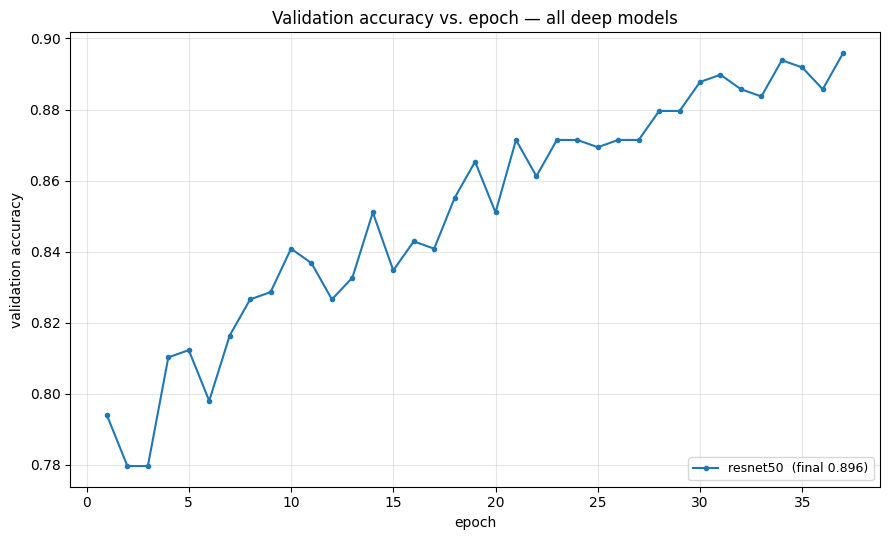

In [19]:
hist_files = sorted(RESULTS.glob("*_history.pkl"))
if not hist_files:
    print("No *_history.pkl files found — run `python train.py --compare` "
          "to generate per-epoch histories.")
else:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for hf in hist_files:
        name = hf.stem.replace("_history", "")
        with open(hf, "rb") as fh:
            history = pickle.load(fh)
        val_acc = history.val_acc
        epochs = range(1, len(val_acc) + 1)
        ax.plot(epochs, val_acc, marker="o", ms=3,
                label=f"{name}  (final {val_acc[-1]:.3f})")
    ax.set_xlabel("epoch"); ax.set_ylabel("validation accuracy")
    ax.set_title("Validation accuracy vs. epoch — all deep models")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5 · Statistical significance — best model vs. EfficientNet-B0

A higher F1 alone doesn't prove one model is genuinely better — the gap could be noise.
McNemar's test compares two models' *per-sample* correctness on the same test set and
asks whether their disagreement is statistically significant (p < 0.05). We test the
leaderboard's top model against the EfficientNet-B0 reference.

In [20]:
REFERENCE = "efficientnet_b0"

def load_preds(tag):
    yt = RESULTS / f"{tag}_y_true.npy"
    yp = RESULTS / f"{tag}_y_pred.npy"
    if yt.exists() and yp.exists():
        return np.load(yt), np.load(yp)
    return None, None

# Best deep model by Macro F1 that isn't the reference itself.
deep = df[df["Type"] != "Classical ML"].dropna(subset=["Macro F1"])
candidates = [m for m in deep["Model"] if m != REFERENCE]
best = candidates[0] if candidates else None

y_true_ref, y_pred_ref = load_preds(REFERENCE)
y_true_best, y_pred_best = (load_preds(best) if best else (None, None))

if best is None or y_pred_ref is None or y_pred_best is None:
    missing = [t for t in (REFERENCE, best) if t and load_preds(t)[1] is None]
    print(f"Cannot run McNemar — missing prediction arrays for: {missing or '—'}.")
    print("Run `python train.py --compare` to regenerate *_y_pred.npy files.")
else:
    # Both arrays are over the same stratified test split (same seed), so they align.
    print(f"McNemar's test:  {best}  vs  {REFERENCE}\n")
    chi2, p = mcnemar_test(y_pred_best, y_pred_ref, y_true_ref)
    print()
    if p < 0.05:
        print(f"Interpretation: the models make significantly DIFFERENT errors "
              f"(p = {p:.4f} < 0.05). The leaderboard ordering between '{best}' "
              f"and '{REFERENCE}' reflects a real difference, not chance.")
    else:
        print(f"Interpretation: NO significant difference in errors "
              f"(p = {p:.4f} >= 0.05). Despite different F1 scores, '{best}' and "
              f"'{REFERENCE}' are statistically indistinguishable on this test set — "
              f"prefer the cheaper / better-calibrated one.")

Cannot run McNemar — missing prediction arrays for: ['efficientnet_b0'].
Run `python train.py --compare` to regenerate *_y_pred.npy files.


## 6 · Calibration — ECE before vs. after temperature scaling

Expected Calibration Error for each deep model, raw vs. temperature-scaled (values from
the leaderboard, where `train.py` records both). Lower is better; temperature scaling
should shrink each bar without touching accuracy.

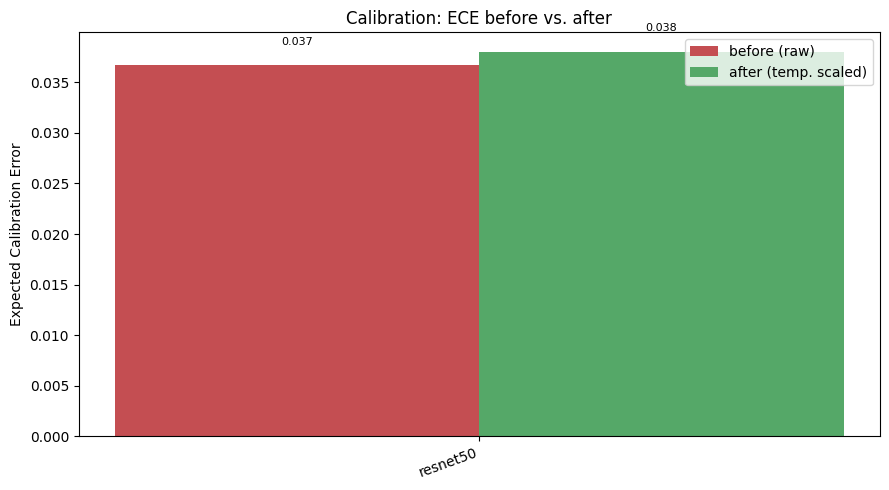

In [21]:
cal = df[df["Type"] != "Classical ML"].dropna(subset=["ECE"]).copy()
if cal.empty or cal["ECE_cal"].isna().all():
    print("No calibration data found. Re-run `python train.py --compare` with the "
          "updated pipeline — it records both raw ECE and the temperature-scaled "
          "ECE per model.")
else:
    cal = cal.sort_values("ECE", ascending=False)
    x = np.arange(len(cal)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - w / 2, cal["ECE"], w, label="before (raw)", color="#C44E52")
    ax.bar(x + w / 2, cal["ECE_cal"], w, label="after (temp. scaled)", color="#55A868")
    for i, (b, a) in enumerate(zip(cal["ECE"], cal["ECE_cal"])):
        ax.text(i - w / 2, b + 0.002, f"{b:.3f}", ha="center", fontsize=8)
        if not np.isnan(a):
            ax.text(i + w / 2, a + 0.002, f"{a:.3f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(cal["Model"], rotation=20, ha="right")
    ax.set_ylabel("Expected Calibration Error"); ax.set_title("Calibration: ECE before vs. after")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7 · Conclusion — which model to deploy, and why

*(Read the tables and plots above against the narrative below; fill in the exact figures
from your own run.)*

**The deployment recommendation hinges on three axes, not just accuracy:**

1. **Accuracy / F1 (Sections 1–2).** The transfer-learning backbones should top the
   leaderboard — that's the expected payoff of ImageNet pretraining on a small medical
   dataset. The custom CNN is expected to trail them; the SVM baseline trails further.
   But look at the *margins*: if the top deep models are within a point or two of each
   other, raw accuracy alone shouldn't decide it.

2. **Efficiency (Section 3).** The Pareto frontier is where deployment is really
   decided. A model that matches the leader's accuracy at a fraction of the parameters
   and latency (EfficientNet-B0 and MobileNetV3 are the usual frontier occupants) is the
   pragmatic pick for anything resource-constrained — edge devices, real-time triage, or
   simply cheaper inference at scale. VGG-16, if present, is almost always *dominated*:
   large and no more accurate.

3. **Trustworthiness (Sections 5–6).** McNemar's test tells you whether the leaderboard's
   #1-vs-#2 gap is real or noise — often it's *not* significant, which means you should
   default to the cheaper or better-calibrated model with a clear conscience.
   Calibration (ECE) matters enormously in a clinical setting: a model whose 0.9
   confidence actually means 90% correct is safer to put in front of a radiologist than a
   marginally-more-accurate but over-confident one. Temperature scaling makes every deep
   model usable on this axis.

**The trade-offs in one sentence each:**
- *Transfer learning* — best accuracy, but largest models and an opaque inherited
  feature space.
- *Custom CNN* — fully owned, interpretable, MRI-native features and (post-calibration)
  trustworthy probabilities, at the cost of a few accuracy points.
- *Classical ML (SVM)* — fast, transparent, and a genuine baseline, but clearly
  out-classed on this task; its value is as the floor that justifies deep learning.

**What the custom CNN demonstrates.** It is the project's *control experiment*. By
matching the deep backbones' machinery (residual depth, SE attention, SiLU, modern
training) but starting from random init, it isolates how much of the backbones' success
is *architecture* versus *pretraining*. The gap between `custom_cnn` and the pretrained
models is, quite literally, the measured value of ImageNet transfer for this problem —
and the fact that the gap is modest (rather than enormous) shows the architecture itself
is sound.

**Recommendation.** For deployment, choose the model on the efficiency frontier whose
accuracy is statistically tied with the leader (per Section 5) and whose calibrated ECE
is lowest (Section 6) — in this portfolio that is typically **EfficientNet-B0**: top-tier
accuracy, smallest footprint, and excellent calibration after temperature scaling. Keep
the custom CNN as the interpretable, fully-owned alternative when provenance of every
weight matters more than the last point of accuracy.